# The Normal Distribution


In [1]:
# Import the usual suspects for data manipulation, statistics, and visualisations.
import pandas as pd # used to "tidy" up and manipulate our data
import numpy as np # used for matrix and numerical calculations; foundation of pandas
from scipy import stats # contains stats functions and is used to visualise probability distributions
import matplotlib.pyplot as plt # used for visualisations
import seaborn as sns # a more user-friendly library used for visualisations

## The Normal distribution

(aka. The "Gaussian" distribution)

This is perhaps the most useful distribution to get comfortable with at this stage in your learning so let's look at some key features.

The normal distribution is used to describe **continuous** random variables, that is, variables that can take any value in a given range. It can be used to approximate **discrete** random variables in some cases.

The normal distribution is the “bell shaped” pattern of data whenever you measure a population or set of scores with some randomness. 
e.g. 
- Measures of size of living tissue
- Physiological measurements, e.g. height, weights, blood pressure of adult humans
- Size of tree-trunks
- The logarithm of exchange rates, price indices, and stock market indices are assumed to follow a Normal distribution
- In science, the measurement errors in experiments are often assumed to be normally distributed

For this reason we can use it as a model in many instances as we are often looking at naturally occuring random variables.

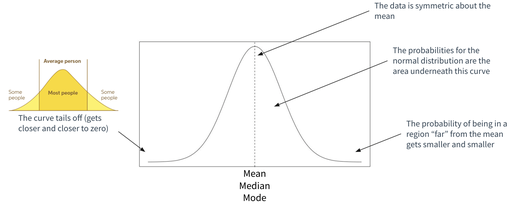

- The mean, median and mode are **equal**
- The distribution is symmetrical and **not** skewed
- Values close to the mean are most likely to occur
- The probability of a value occuring tails off either side of the mean so that the probability of a value being more or less than three standard deviations from the mean is close to zero



### The Empirical Rule

The normal distribution has the following property:
- 68.2% of the data will lie within one standard deviation around the mean
- 95.4% of the data will lie within two standard deviations around the mean
- 99.7% of the data will lie within three standard deviations around the mean

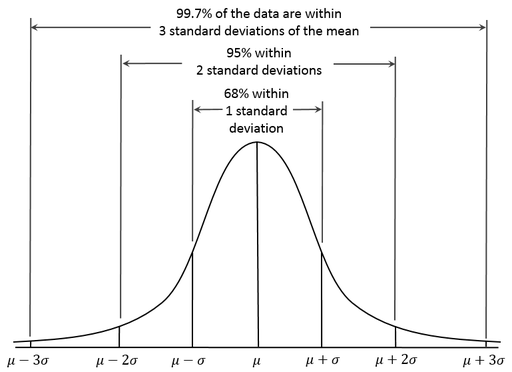

### Defining parameters

The normal distribution can take many different shapes depending on the values of the two **key parameters** that define it:

- The mean (often referred to as "mu" $\mu$ in the notation) 
- The standard deviaton (often referred to as "sigma" $\sigma$)

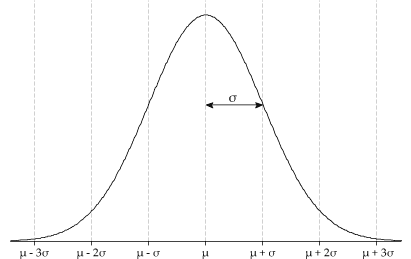

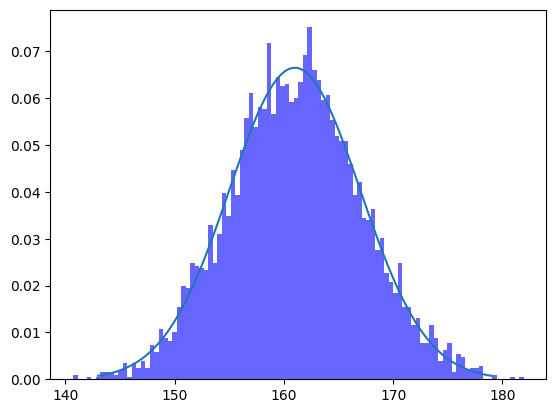

In [2]:
# We will explore effect of changing the values of mu and sigma on the graph of the normal distribution
# We will also look at how to draw a random sample from a normal distribution and the effect of sample size on fit

# Define the parameters of the distribution
mu = 161
sigma = 6

# Plot the normal curve for the above parameters
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma))

# We can also generate random samples from a distribution with any mean and standard deviation
x = np.random.normal(mu, sigma, size=5000)

# Plot the histogram
plt.hist(x, bins=100, density=True, alpha=0.6, color='b')

plt.show()

In [3]:
# Many naturally occuring measurements are normally distributed so we will look at some heights data to illustrate
# Load the data into a pandas dataframe called 'df' using pandas read_csv

df = pd.read_csv("data/weight-height.csv")

In [4]:

df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [5]:
df.Height.describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Count'>

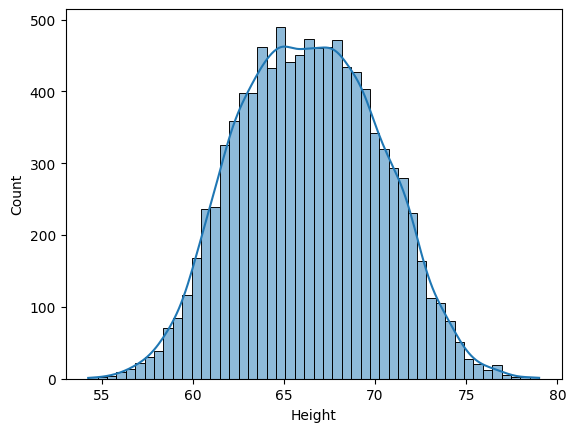

In [6]:
# Many times during data exploration you might want to plot this kind of histogram to look at the distribution

sns.histplot(df.Height, kde=True)

In [7]:
# We might also want to review the mean median and mode to check the data is sufficiently symmetrical
# This helps us to decide is the normal distribution is a suitable model

x = df.Height.mean()
y = df.Height.median()
z = stats.mode(df.Height)

print("The mean height is %g, the median height is %g and the modal height is %g" %(x,y,z[0]))

The mean height is 66.3676, the median height is 66.3181 and the modal height is 54.2631


<font color='green'> 
    
### Discussion point 
Do you think a normal distribution would be an appropriate model for the heights data?



### Outlier identification

There are many different ways that we can identify outliers.

In a normal distribution the probability of a data point existing that falls more than three standard deviations away from the mean is very small. We could therefore define values lying outside this to be outliers.

Such outliers can **skew** our model and it might be appropriate to remove them in some cases. This is an example of an application in data cleaning.

In [8]:
mean = df.Height.mean()
std_deviation = df.Height.std()
mean - 3*std_deviation

54.82497539250156

In [9]:
# Identifying outliers

df[(df.Height > 77.91) | (df.Height < 54.82)]

,Gender,Height,Weight
994,Male,78.095867,255.690835
1317,Male,78.462053,227.342565
2014,Male,78.998742,269.989699
3285,Male,78.528210,253.889004
3757,Male,78.621374,245.733783
6624,Female,54.616858,71.393749
9285,Female,54.263133,64.700127


In [10]:
df_no_outlier = df[(df.Height < 77.91) & (df.Height > 54.82)]


df_no_outlier.describe()

,Height,Weight
count,9993.000000,9993.000000
mean,66.363856,161.414473
std,3.835511,32.028986
min,54.873728,68.982530
25%,63.505894,135.819094
50%,66.317755,161.193433
75%,69.169353,187.120945
max,77.547186,255.863326


## Calculating probabilities from the normal distribution (p-values)

If we have a dataset that appears to be **normally distributed** we can use the normal curve as a model to predict the probabilities of different outcomes.

We just need to know the mean and standard deviation that would define the unique curve to fit our data and we can use this to **look up** the corresponding probabilities of variable values. 

The normal distribution is a **continuous** distribution therefore is it not possible to define probabilities of exact values.

However we are able to calculate probabilties for **ranges of values** - these probabilities are known as **cumulative probabilities**.



**Examples**

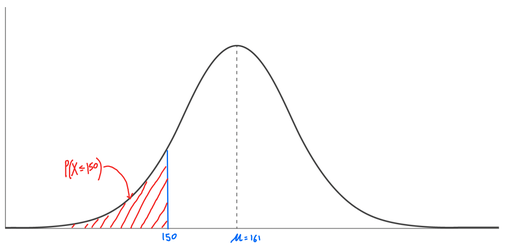



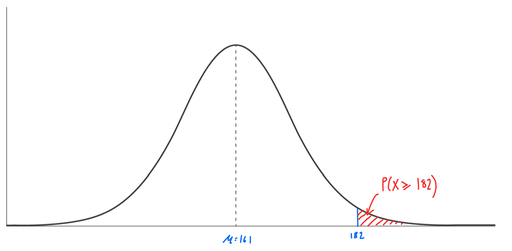


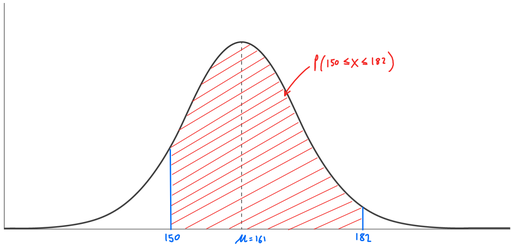


In [11]:
# As an example let's calculate the theoretical probability of the outlier heights occuring

# Define distribution of variable
x = stats.norm(161,7)

# Use stats.norm.cdf to return cumulative probabilities for "less than"
# Use stats.norm.sf to return cumulative probabilities for "greater than"
# For probabilities "between" subtract two probabilities from one another using stats.norm.cdf

# Diagram 1
p_value1 = stats.norm(161,7).cdf(150)
print(p_value1)

# Diagram 2
p_value2 = stats.norm(161,7).sf(182)
print(p_value2)

# Diagram 3
p_value3 = stats.norm(161,7).cdf(182) - stats.norm(161,7).cdf(150)
print(p_value3)

# Experiment here with some others

0.05804156686932752
0.0013498980316300933
0.9406085350990424


In [12]:
# It's also possible to work backwards from a probabilty to a "critial value" of our variable

# e.g. to return the height for which the probabilty of being less than that height is 0.25:
stats.norm(161,7).ppf(0.25)

# Experiment here with some others

156.27857174862743

## Z-scores 

If you know about standard deviation, then you already know what a z-score is!

In relation to a normal distribution, the z-score is just the **number of standard deviations** that a given data point is away from the mean.

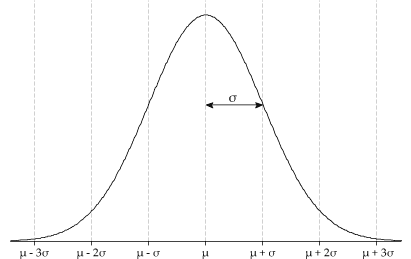

If I have a data point that is 2 standard deviations from the mean then the z-score will be 2.

If I have a data point that is -1.5 standard deviations from the mean then the z-score will be -1.5.

And so on!

### Applications

Z-scores can be used for example to identify outliers in a dataset that is normally distributed.

### Calculating the z-score

In order to calculate the z-score we just need to subtract the mean from our data point and divide by the standard deviation:

$$ z = \frac{x_{i} - \mu}{\sigma}$$


In [13]:
# Say I wanted to calculate a z-score for a height of 150

mu = 161
sigma = 7

z = (150 - mu) / sigma
z

-1.5714285714285714

In [14]:
# Say I wanted to calculate a z-score for every item in my heights dataset

df['zscore'] = (df.Height - df.Height.mean())/df.Height.std()

In [15]:
df.head()

,Gender,Height,Weight,zscore
0,Male,73.847017,241.893563,1.943964
1,Male,68.781904,162.310473,0.627505
2,Male,74.110105,212.740856,2.012343
3,Male,71.730978,220.042470,1.393991
4,Male,69.881796,206.349801,0.913375


In [16]:
# Example of sorting for outliers

df[(df.zscore>3) | (df.zscore<-3)]

,Gender,Height,Weight,zscore
994,Male,78.095867,255.690835,3.048271
1317,Male,78.462053,227.342565,3.143445
2014,Male,78.998742,269.989699,3.282934
3285,Male,78.528210,253.889004,3.160640
3757,Male,78.621374,245.733783,3.184854
6624,Female,54.616858,71.393749,-3.054091
9285,Female,54.263133,64.700127,-3.146027


### Applications continued

Both z-scores and p-values can be used as a measure of **significance**. The lower the z-score, the more typical a data point is and the more likely it is to occur. Higher z-scores are less typical and are less likely to occur. Equally, we could say that a p-value of less than say 1% means that a data point is not typical, or a p-value of 25% is more typical, and so on.

Z-scores can also be used to set **critical values** of a test statistic above or below which we deem it to be "statistically significant". This can be useful for drawing conclusions for example in hypothesis tests. p-values can be used in the same way also.





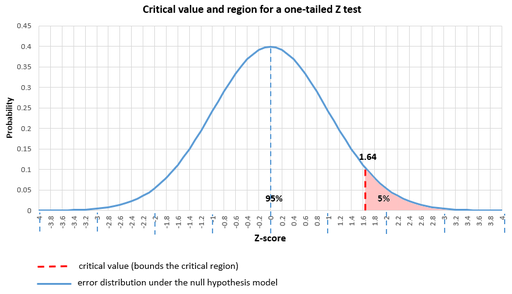

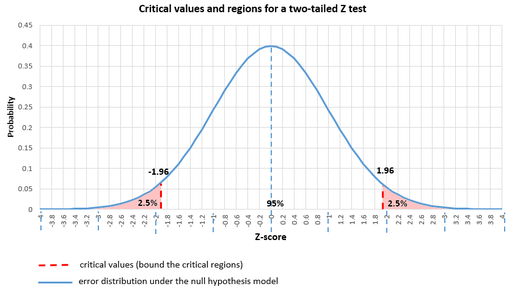

In [17]:
# For example the probability of being more than c. 1.64 standard deviations from the mean is has a 5% probability

# Rearranging the formula for z

critical_value = 1.64 * df.Height.std() + df.Height.mean()

critical_value

72.67750587288934

In [18]:
# We can now check the probability of being taller than 72.68

p_value = stats.norm(df.Height.mean(),df.Height.std()).sf(72.68)
p_value

0.05043522740027241

## Summary

In this section we have got familiar with the normal distribution.

You should:
- be comfortable with the concept of a normal distribution
- understand when we can use it as a model
- know how to calculate p-values and z-scores for different values of a normally distributed random variable
- understand what the p-values and z-scores mean and how they might indicate statistical significance